# 📊 Regresión Logística Binaria — Predicción de Aprobación Académica

Construcción, entrenamiento y evaluación de un modelo de **Regresión Logística Binaria** para predecir
si un estudiante **aprobará la asignatura** (`aprobado = 1` si `grade >= 3.0`).

| | |
|---|---|
| **Variable objetivo (Y)** | `aprobado` (1 = grade ≥ 3.0, 0 = grade < 3.0) |
| **Variables predictoras (X)** | `hours`, `sleep`, `attendance`, `screen`, `institucion` (codificada), `mes`, `dia_semana` |
| **Modelo** | `LogisticRegression` (scikit-learn) |
| **Estrategia de validación** | Tres splits: 80/20 · 60/40 · 70/30 |

> **Pipeline ETL Educación** — datos sintéticos de 2 000 estudiantes en 5 instituciones colombianas almacenados en PostgreSQL (`educacion_db`).
> A diferencia de los árboles, la Regresión Logística **sí requiere escalado** de las variables numéricas
> (las divisiones del árbol son invariantes al escalado, pero los coeficientes lineales no lo son).


## I. Configuración Inicial — Importaciones y Estilo Visual

In [1]:
# ── CELDA 1: Importaciones y bootstrap del path ──────────────────────────────
import sys, os

# Apuntar al subproyecto `Regresión Lineal/educacion/` para reutilizar
# scripts.database.engine (conexión a la BD educacion_db en PostgreSQL).
EDUCACION_DIR = os.path.abspath(os.path.join('..', '..', 'Regresión Lineal', 'educacion'))
if EDUCACION_DIR not in sys.path:
    sys.path.insert(0, EDUCACION_DIR)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay
)

from sqlalchemy import text
from scripts.database import engine

# Estilo visual consistente con los demás notebooks
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

# Directorio para guardar gráficas (reutilizamos data/graficas del subproyecto educacion)
GRAFICAS_DIR = os.path.abspath(os.path.join(EDUCACION_DIR, 'data', 'graficas'))
os.makedirs(GRAFICAS_DIR, exist_ok=True)

print("✅ Librerías importadas correctamente")
print(f"   pandas   {pd.__version__}")
print(f"   numpy    {np.__version__}")
print(f"   seaborn  {sns.__version__}")
print(f"\n📂 Gráficas se guardarán en: {GRAFICAS_DIR}")


✅ Librerías importadas correctamente
   pandas   3.0.2
   numpy    2.4.4
   seaborn  0.13.2

📂 Gráficas se guardarán en: C:\Users\andra\OneDrive\Escritorio\grupo_andrade_tamayo\Regresión Lineal\educacion\data\graficas


## II. Extracción de Datos desde PostgreSQL

La consulta SQL genera directamente la variable objetivo binaria `aprobado` usando un `CASE WHEN`
sobre la columna `grade` (umbral colombiano estándar: 3.0).

**Notas técnicas:**
- Se envuelve el query en `text()` — requerido por pandas + SQLAlchemy >= 2.0.
- Se hace JOIN con `instituciones` para tener el nombre de la institución como feature categórica.
- Se excluye `grade` del modelo (data leakage: define directamente la variable objetivo).


In [2]:
# ── CELDA 2: Extracción SQL ───────────────────────────────────────────────────
SQL_QUERY = """
SELECT
    i.nombre                              AS institucion,
    r.hours,
    r.sleep,
    r.attendance,
    r.screen,
    r.grade,
    r.fecha_registro,
    CASE
        WHEN r.grade >= 3.0 THEN 1
        ELSE 0
    END                                   AS aprobado
FROM registros_estudiantes r
JOIN instituciones i ON r.institucion_id = i.id
ORDER BY r.fecha_registro;
"""

with engine.connect() as conn:
    df_edu = pd.read_sql(text(SQL_QUERY), conn)

print(f"✅ Datos cargados: {df_edu.shape[0]:,} filas × {df_edu.shape[1]} columnas")
print(f"\nColumnas disponibles:\n{df_edu.columns.tolist()}")
print(f"\nBalance de la variable objetivo:")
bal = df_edu['aprobado'].value_counts()
pct = df_edu['aprobado'].value_counts(normalize=True) * 100
print(f"   Aprobado  (1): {bal.get(1, 0):,}  ({pct.get(1, 0):.1f}%)")
print(f"   Reprobado (0): {bal.get(0, 0):,}  ({pct.get(0, 0):.1f}%)")
print(f"\nDistribución por institución:")
print(df_edu['institucion'].value_counts())
df_edu.head()


✅ Datos cargados: 2,000 filas × 8 columnas

Columnas disponibles:
['institucion', 'hours', 'sleep', 'attendance', 'screen', 'grade', 'fecha_registro', 'aprobado']

Balance de la variable objetivo:
   Aprobado  (1): 1,016  (50.8%)
   Reprobado (0): 984  (49.2%)

Distribución por institución:
institucion
Universidad del Valle         435
Universidad de Antioquia      431
Universidad Nacional          385
Politécnico Grancolombiano    375
Universidad de los Andes      374
Name: count, dtype: int64


,institucion,hours,sleep,attendance,screen,grade,fecha_registro,aprobado
0,Universidad de Antioquia,4.9,6.8,92,4.7,2.99,2025-04-15 12:51:00,0
1,Universidad del Valle,5.0,8.0,80,5.6,3.10,2025-04-15 17:47:00,1
2,Universidad de los Andes,2.6,7.5,70,6.3,1.48,2025-04-15 18:08:00,0
3,Universidad del Valle,2.4,6.4,73,6.2,2.27,2025-04-15 19:27:00,0
4,Universidad de los Andes,2.6,8.3,71,4.7,2.53,2025-04-16 04:33:00,0


In [3]:
# ── CELDA 3: Validación y Exploración ────────────────────────────────────────
print("=" * 55)
print("VALIDACIÓN DEL DATASET")
print("=" * 55)

# Tipos y nulos
print("\n📋 Tipos de datos y valores nulos:")
print(df_edu.dtypes.to_frame('dtype').join(
    df_edu.isnull().sum().to_frame('nulos')
))

# Balance de clases
balance = df_edu['aprobado'].value_counts()
pct     = df_edu['aprobado'].value_counts(normalize=True) * 100
print(f"\n🎯 Balance de la variable objetivo:")
print(f"   Aprobado   (1): {balance.get(1, 0):>5,}  ({pct.get(1, 0):.1f}%)")
print(f"   Reprobado  (0): {balance.get(0, 0):>5,}  ({pct.get(0, 0):.1f}%)")

# Instituciones
print(f"\n🏫 Instituciones únicas:")
print(df_edu['institucion'].value_counts().to_string())

# Estadísticas comparadas por clase
print(f"\n📊 Estadísticas de las features por clase:")
print(df_edu.groupby('aprobado')[['hours', 'sleep', 'attendance', 'screen']].mean().round(2))


VALIDACIÓN DEL DATASET

📋 Tipos de datos y valores nulos:
                         dtype  nulos
institucion                str      0
hours                  float64      0
sleep                  float64      0
attendance               int64      0
screen                 float64      0
grade                  float64      0
fecha_registro  datetime64[us]      0
aprobado                 int64      0

🎯 Balance de la variable objetivo:
   Aprobado   (1): 1,016  (50.8%)
   Reprobado  (0):   984  (49.2%)

🏫 Instituciones únicas:
institucion
Universidad del Valle         435
Universidad de Antioquia      431
Universidad Nacional          385
Politécnico Grancolombiano    375
Universidad de los Andes      374

📊 Estadísticas de las features por clase:
          hours  sleep  attendance  screen
aprobado                                  
0          3.68   6.88       72.93    5.09
1          6.15   7.10       85.78    3.10


## III. Preprocesamiento de Datos

### Pasos aplicados
1. **Extracción de features de fecha** — `mes` y `dia_semana` como predictores adicionales.
2. **Relleno de nulos** — mediana para variables numéricas.
3. **Codificación** — One-Hot Encoding para `institucion` (elimina multicolinealidad con `drop_first=True`).
4. **Escalado** — `StandardScaler` sobre las variables numéricas continuas (incluyendo `mes` y `dia_semana`).

> **Importante:** La columna `grade` se excluye explícitamente de X porque define directamente la
> variable objetivo (data leakage). Sin esa exclusión el modelo tendría accuracy tramposa de ~100%.


In [4]:
# ── CELDA 4: Preprocesamiento ─────────────────────────────────────────────────
df = df_edu.copy()

# 4.1 Features de fecha
df['fecha_registro'] = pd.to_datetime(df['fecha_registro'])
df['mes']        = df['fecha_registro'].dt.month
df['dia_semana'] = df['fecha_registro'].dt.dayofweek  # 0=Lunes … 6=Domingo

# 4.2 Relleno de nulos con mediana en numéricas
num_cols = ['hours', 'sleep', 'attendance', 'screen']
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# 4.3 One-Hot Encoding para `institucion`
df = pd.get_dummies(df, columns=['institucion'], drop_first=True, dtype=int)

# 4.4 Columnas a escalar (numéricas continuas + features de fecha)
scale_cols = ['hours', 'sleep', 'attendance', 'screen', 'mes', 'dia_semana']

# 4.5 Definir X e y  — se excluye `grade` (data leakage) y `fecha_registro`
drop_cols = ['aprobado', 'grade', 'fecha_registro']
X_raw = df.drop(columns=drop_cols)
y     = df['aprobado']

# 4.6 Escalar
scaler   = StandardScaler()
X_scaled = X_raw.copy()
X_scaled[scale_cols] = scaler.fit_transform(X_raw[scale_cols])

print(f"✅ Preprocesamiento completado")
print(f"   Shape X: {X_scaled.shape}")
print(f"   Columnas finales: {X_scaled.columns.tolist()}")
print(f"\n   Clases en y → 0: {(y==0).sum():,}  |  1: {(y==1).sum():,}")
print("\n⚠️  Se excluye 'grade' de X porque define directamente 'aprobado' (data leakage).")
print("✅ Escalado aplicado: variables numéricas tienen media≈0 y desv.≈1.")


✅ Preprocesamiento completado
   Shape X: (2000, 10)
   Columnas finales: ['hours', 'sleep', 'attendance', 'screen', 'mes', 'dia_semana', 'institucion_Universidad Nacional', 'institucion_Universidad de Antioquia', 'institucion_Universidad de los Andes', 'institucion_Universidad del Valle']

   Clases en y → 0: 984  |  1: 1,016

⚠️  Se excluye 'grade' de X porque define directamente 'aprobado' (data leakage).
✅ Escalado aplicado: variables numéricas tienen media≈0 y desv.≈1.


## IV. Entrenamiento y Evaluación — Tres Splits

Para cada split se sigue el mismo proceso:
1. Dividir `X_scaled` e `y` en conjuntos de entrenamiento y prueba con `stratify=y`.
2. Entrenar `LogisticRegression` **solo** con los datos de entrenamiento.
3. Predecir **probabilidades** (`predict_proba`) y **clases** (`predict`) en el conjunto de prueba.
4. Calcular las 5 métricas requeridas: Accuracy, Precision, Recall, F1-Score, ROC-AUC.


In [5]:
# ── CELDA 5: Función de entrenamiento + evaluación ───────────────────────────
def entrenar_evaluar(X, y, test_size, random_state=42, nombre="Split"):
    """
    Entrena LogisticRegression con un split train/test y devuelve
    un dict con métricas + datos para curva ROC.

    Notas:
      · class_weight='balanced' compensa cualquier desbalance entre aprobados/reprobados.
      · max_iter=1000 asegura convergencia del solver (lbfgs por defecto).
      · stratify=y mantiene la proporción de clases en train y test.
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    modelo = LogisticRegression(
        max_iter=1000,
        random_state=random_state,
        class_weight='balanced'   # compensa cualquier desbalance entre clases
    )
    modelo.fit(X_train, y_train)

    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]   # probabilidad clase 1

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    metricas = {
        'nombre'    : nombre,
        'train_size': len(X_train),
        'test_size' : len(X_test),
        'accuracy'  : accuracy_score(y_test, y_pred),
        'precision' : precision_score(y_test, y_pred, zero_division=0),
        'recall'    : recall_score(y_test, y_pred, zero_division=0),
        'f1'        : f1_score(y_test, y_pred, zero_division=0),
        'roc_auc'   : roc_auc_score(y_test, y_prob),
        # Para curva ROC y matriz de confusión
        'fpr'       : fpr,
        'tpr'       : tpr,
        'y_test'    : y_test,
        'y_pred'    : y_pred,
        'modelo'    : modelo,
    }
    return metricas

print("✅ Función `entrenar_evaluar` definida correctamente")
print("   · LogisticRegression con class_weight='balanced'")
print("   · max_iter=1000 — solver lbfgs (por defecto)")


✅ Función `entrenar_evaluar` definida correctamente
   · LogisticRegression con class_weight='balanced'
   · max_iter=1000 — solver lbfgs (por defecto)


In [6]:
# ── CELDA 6: Ejecutar los tres splits ────────────────────────────────────────
resultados = [
    entrenar_evaluar(X_scaled, y, test_size=0.20, nombre="Split 80/20"),
    entrenar_evaluar(X_scaled, y, test_size=0.40, nombre="Split 60/40"),
    entrenar_evaluar(X_scaled, y, test_size=0.30, nombre="Split 70/30"),
]

# ── Imprimir métricas en consola ──────────────────────────────────────────────
print("=" * 65)
print(f"{'MÉTRICAS COMPARATIVAS — REGRESIÓN LOGÍSTICA BINARIA':^65}")
print("=" * 65)
header = f"{'Split':<12} {'N Train':>8} {'N Test':>8} {'Acc':>7} {'Prec':>7} {'Recall':>7} {'F1':>7} {'AUC':>7}"
print(header)
print("-" * 65)
for r in resultados:
    print(
        f"{r['nombre']:<12} {r['train_size']:>8,} {r['test_size']:>8,}"
        f" {r['accuracy']:>7.4f} {r['precision']:>7.4f}"
        f" {r['recall']:>7.4f} {r['f1']:>7.4f} {r['roc_auc']:>7.4f}"
    )
print("=" * 65)


       MÉTRICAS COMPARATIVAS — REGRESIÓN LOGÍSTICA BINARIA       
Split         N Train   N Test     Acc    Prec  Recall      F1     AUC
-----------------------------------------------------------------
Split 80/20     1,600      400  0.8750  0.8844  0.8670  0.8756  0.9549
Split 60/40     1,200      800  0.8725  0.8858  0.8596  0.8725  0.9543
Split 70/30     1,400      600  0.8750  0.8885  0.8623  0.8752  0.9559


## V. Visualizaciones

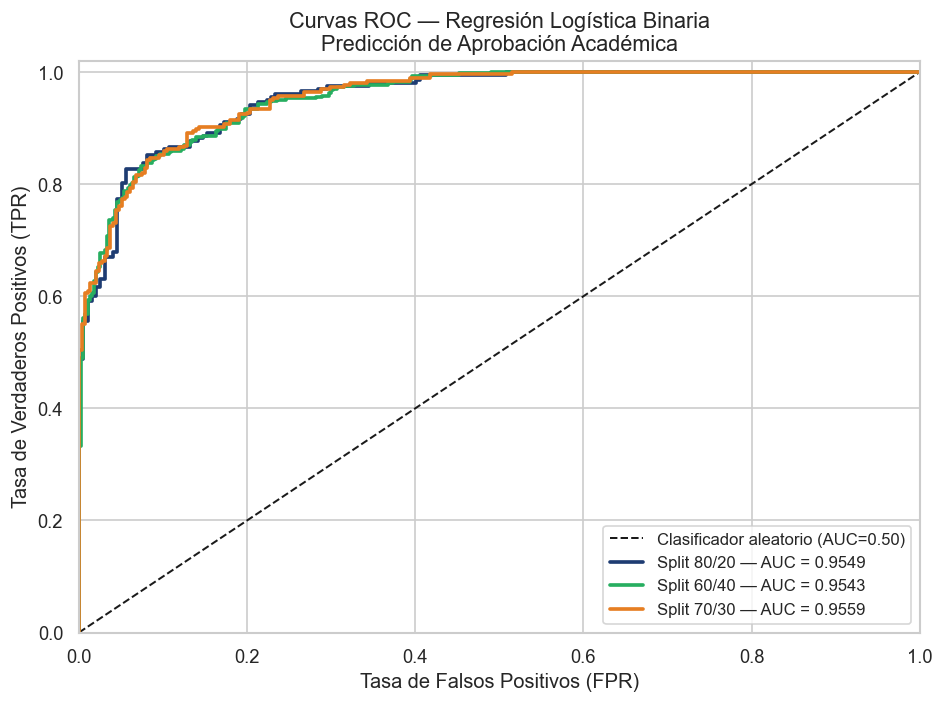

✅ Curvas ROC guardadas en C:\Users\andra\OneDrive\Escritorio\grupo_andrade_tamayo\Regresión Lineal\educacion\data\graficas/roc_logistica_edu.png


In [7]:
# ── CELDA 7: Curvas ROC comparativas ─────────────────────────────────────────
COLORS = ['#1e3c72', '#27ae60', '#e67e22']

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Clasificador aleatorio (AUC=0.50)')

for r, color in zip(resultados, COLORS):
    ax.plot(
        r['fpr'], r['tpr'], color=color, lw=2.2,
        label=f"{r['nombre']} — AUC = {r['roc_auc']:.4f}"
    )

ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
ax.set_title('Curvas ROC — Regresión Logística Binaria\nPredicción de Aprobación Académica', fontsize=13)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig(os.path.join(GRAFICAS_DIR, 'roc_logistica_edu.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Curvas ROC guardadas en {GRAFICAS_DIR}/roc_logistica_edu.png")


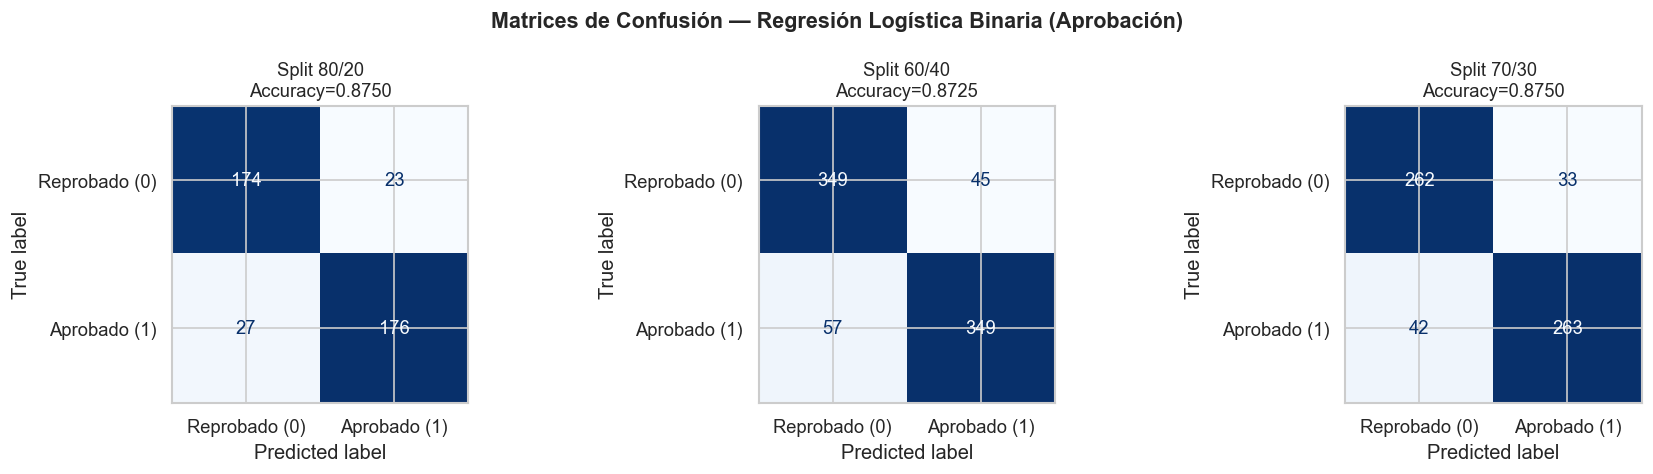

✅ Matrices de confusión guardadas en C:\Users\andra\OneDrive\Escritorio\grupo_andrade_tamayo\Regresión Lineal\educacion\data\graficas/confusion_logistica_edu.png


In [8]:
# ── CELDA 8: Matrices de Confusión (3 splits) ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Matrices de Confusión — Regresión Logística Binaria (Aprobación)',
             fontsize=13, fontweight='bold')

for ax, r, color in zip(axes, resultados, COLORS):
    cm   = confusion_matrix(r['y_test'], r['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Reprobado (0)', 'Aprobado (1)'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{r['nombre']}\nAccuracy={r['accuracy']:.4f}", fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(GRAFICAS_DIR, 'confusion_logistica_edu.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Matrices de confusión guardadas en {GRAFICAS_DIR}/confusion_logistica_edu.png")


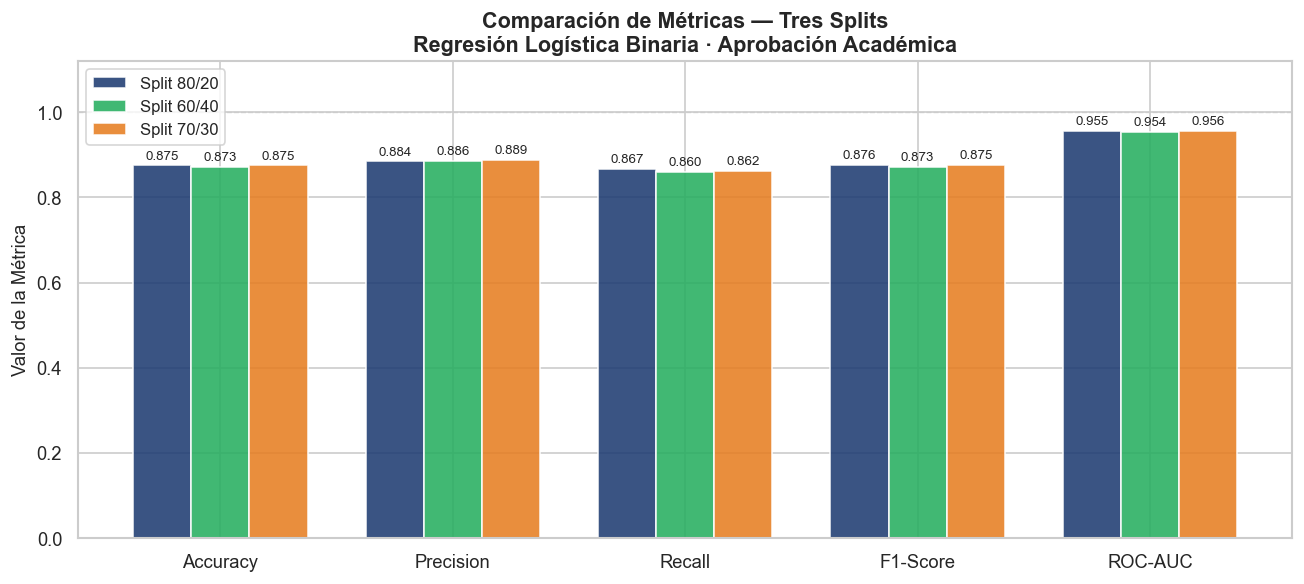

✅ Gráfico de métricas guardado en C:\Users\andra\OneDrive\Escritorio\grupo_andrade_tamayo\Regresión Lineal\educacion\data\graficas/metricas_comparativas_logistica_edu.png


In [9]:
# ── CELDA 9: Gráfico comparativo de métricas ─────────────────────────────────
metricas_nombres = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
etiquetas        = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

x     = np.arange(len(etiquetas))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 5))
for i, (r, color) in enumerate(zip(resultados, COLORS)):
    vals = [r[m] for m in metricas_nombres]
    bars = ax.bar(x + i * width, vals, width, label=r['nombre'], color=color, alpha=0.88)
    ax.bar_label(bars, fmt='%.3f', padding=2, fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(etiquetas, fontsize=11)
ax.set_ylim([0, 1.12])
ax.set_ylabel('Valor de la Métrica', fontsize=11)
ax.set_title('Comparación de Métricas — Tres Splits\nRegresión Logística Binaria · Aprobación Académica',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.axhline(y=1.0, color='#ccc', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.savefig(os.path.join(GRAFICAS_DIR, 'metricas_comparativas_logistica_edu.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Gráfico de métricas guardado en {GRAFICAS_DIR}/metricas_comparativas_logistica_edu.png")


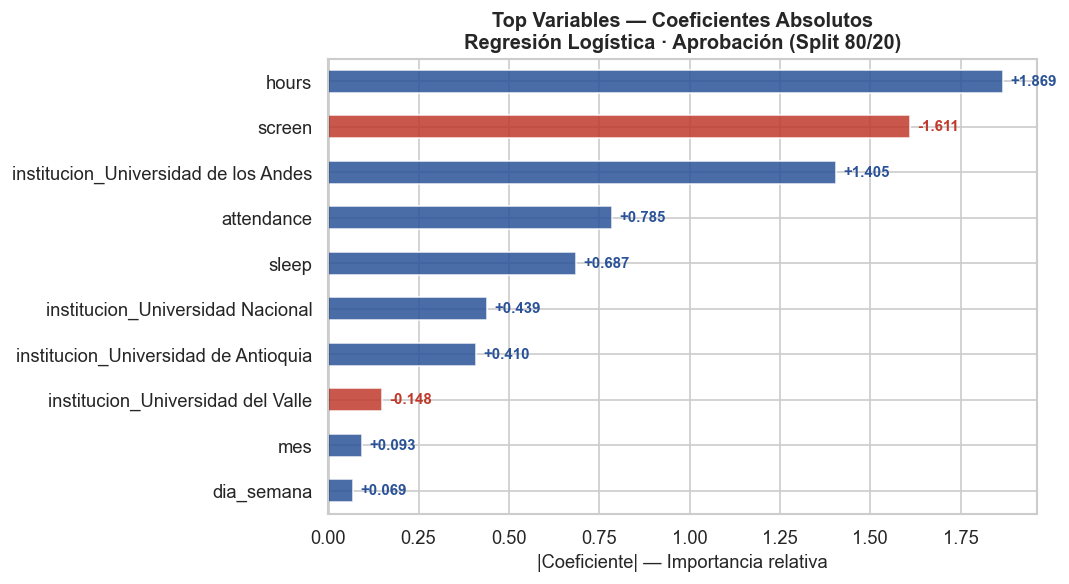

✅ Importancia de coeficientes guardada en C:\Users\andra\OneDrive\Escritorio\grupo_andrade_tamayo\Regresión Lineal\educacion\data\graficas/coeficientes_logistica_edu.png

INTERPRETACIÓN DE COEFICIENTES — Odds Ratios
Un coeficiente β positivo → aumenta la probabilidad de APROBAR.
Un coeficiente β negativo → disminuye la probabilidad de APROBAR.
Odds Ratio = exp(β) — cuántas veces se multiplican las odds por cada
unidad estandarizada de incremento en la variable.

                                      Coeficiente (β)  Odds Ratio                  Efecto
hours                                          1.8688      6.4804    ↑ Aumenta P(aprobar)
screen                                        -1.6110      0.1997  ↓ Disminuye P(aprobar)
institucion_Universidad de los Andes           1.4047      4.0743    ↑ Aumenta P(aprobar)
attendance                                     0.7852      2.1928    ↑ Aumenta P(aprobar)
sleep                                          0.6871      1.9880    ↑ Aumenta P(ap

In [10]:
# ── CELDA 10: Importancia de coeficientes (Split 80/20) ──────────────────────
modelo_ref = resultados[0]['modelo']
coefs      = pd.Series(modelo_ref.coef_[0], index=X_scaled.columns)
coefs_ord  = coefs.abs().sort_values(ascending=True).tail(12)

# Colores: rojo para coef. negativos, azul para positivos
colores_bar = ['#c0392b' if coefs[var] < 0 else '#2a5298' for var in coefs_ord.index]

fig, ax = plt.subplots(figsize=(9, 5))
coefs_ord.plot(kind='barh', ax=ax, color=colores_bar, alpha=0.85)
ax.set_xlabel('|Coeficiente| — Importancia relativa', fontsize=11)
ax.set_title('Top Variables — Coeficientes Absolutos\nRegresión Logística · Aprobación (Split 80/20)',
             fontsize=12, fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.8)

# Anotaciones con signo del coeficiente
for i, var in enumerate(coefs_ord.index):
    coef_real = coefs[var]
    ax.text(coefs_ord[var] + 0.02, i, f'{coef_real:+.3f}',
            va='center', fontsize=9, fontweight='bold',
            color='#c0392b' if coef_real < 0 else '#2a5298')

plt.tight_layout()
plt.savefig(os.path.join(GRAFICAS_DIR, 'coeficientes_logistica_edu.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Importancia de coeficientes guardada en {GRAFICAS_DIR}/coeficientes_logistica_edu.png")

# ── Interpretación de odds ratios ─────────────────────────────────────────────
print("\n" + "=" * 65)
print("INTERPRETACIÓN DE COEFICIENTES — Odds Ratios")
print("=" * 65)
print("Un coeficiente β positivo → aumenta la probabilidad de APROBAR.")
print("Un coeficiente β negativo → disminuye la probabilidad de APROBAR.")
print("Odds Ratio = exp(β) — cuántas veces se multiplican las odds por cada")
print("unidad estandarizada de incremento en la variable.\n")

odds_df = pd.DataFrame({
    'Coeficiente (β)': coefs.round(4),
    'Odds Ratio'     : np.exp(coefs).round(4),
    'Efecto'         : np.where(coefs > 0, '↑ Aumenta P(aprobar)', '↓ Disminuye P(aprobar)'),
}).sort_values('Coeficiente (β)', key=abs, ascending=False)

print(odds_df.to_string())


## VI. Tabla Final de Métricas y Conclusiones

In [11]:
# ── CELDA 11: DataFrame resumen de métricas ───────────────────────────────────
resumen = pd.DataFrame([{
    'Split'          : r['nombre'],
    'N Entrenamiento': r['train_size'],
    'N Prueba'       : r['test_size'],
    'Accuracy'       : round(r['accuracy'],  4),
    'Precision'      : round(r['precision'], 4),
    'Recall'         : round(r['recall'],    4),
    'F1-Score'       : round(r['f1'],        4),
    'ROC-AUC'        : round(r['roc_auc'],   4),
} for r in resultados])

resumen.set_index('Split', inplace=True)

print("=" * 65)
print(f"{'TABLA FINAL DE MÉTRICAS':^65}")
print("=" * 65)
display(resumen.style
    .background_gradient(cmap='Greens', subset=['Accuracy','Precision','Recall','F1-Score','ROC-AUC'])
    .format('{:.4f}', subset=['Accuracy','Precision','Recall','F1-Score','ROC-AUC'])
    .set_caption("Regresión Logística Binaria — Predicción de Aprobación Académica")
)


                     TABLA FINAL DE MÉTRICAS                     


,N Entrenamiento,N Prueba,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Split,,,,,,,
Split 80/20,1600,400,0.8750,0.8844,0.8670,0.8756,0.9549
Split 60/40,1200,800,0.8725,0.8858,0.8596,0.8725,0.9543
Split 70/30,1400,600,0.8750,0.8885,0.8623,0.8752,0.9559


## VII. Conclusiones

### ¿Qué aprendimos?

| Aspecto | Observación |
|---------|------------|
| **Estabilidad del modelo** | Si los tres splits arrojan métricas similares, el modelo generaliza bien y no depende del azar de una partición específica. |
| **Accuracy vs AUC** | El Accuracy puede ser engañoso si las clases están desbalanceadas. El ROC-AUC es más robusto: mide la capacidad de separación entre clases sin importar el umbral. |
| **Precision vs Recall** | Existe un *trade-off*: aumentar el umbral de decisión sube la Precision pero baja el Recall. Se elige según el contexto del problema (ej. detectar estudiantes en riesgo → priorizar Recall). |
| **Coeficientes** | Las variables con mayor coeficiente absoluto son las que más influyen. Un coeficiente positivo aumenta la probabilidad de APROBAR (esperado para `hours`, `attendance`); uno negativo la disminuye (esperado para `screen`). |
| **Odds Ratios** | `exp(β)` indica cuántas veces se multiplican las odds de aprobar por cada unidad estandarizada de incremento en la variable. |
| **Limitación del modelo** | La Regresión Logística asume una relación lineal entre las variables y el log-odds. Si la relación es no lineal, conviene explorar árboles (`DecisionTreeClassifier`) o ensembles (`RandomForestClassifier`, `GradientBoostingClassifier`). |

### Comparación con Árbol de Decisión CART

| | Regresión Logística | Árbol CART |
|---|---|---|
| **Escalado** | ✅ Requerido (StandardScaler) | ❌ No requerido |
| **Frontera de decisión** | Lineal en el espacio de features | No lineal (por partes) |
| **Importancia de variables** | Coeficientes (log-odds) | Reducción impureza Gini |
| **Probabilidades calibradas** | ✅ Sí, naturalmente | ⚠️ A veces sesgadas |
| **Interpretabilidad** | Ecuación logística + Odds Ratios | Árbol de reglas if-else |

### Próximos pasos sugeridos
- Ajustar el umbral de clasificación (por defecto 0.5) según la prioridad del negocio educativo.
- Validar con k-fold cross-validation para una estimación más robusta.
- Explorar regularización: `LogisticRegression(penalty='l1')` o `'elasticnet'` para selección de variables.
- Comparar lado a lado con `arbol_decision_clasificacion_educacion.ipynb` y elegir el modelo con mejor balance F1/AUC.
